In [ ]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [ ]:
%%capture
!pip -q install lightning torchinfo

## RNN Model Design (MNIST-RNN)

### **Import Module**

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

### **DataSet**

#### Load

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
mnist_transform = transforms.ToTensor()

from torchvision.datasets import MNIST

download_root = './' # ./MNIST
batch_size = 512

train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=mnist_transform, train=False, download=True)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.33MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 125kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.89MB/s]


In [ ]:
ps(next(iter(train_loader))[0])
ps(next(iter(train_loader))[1])

[] Shapetorch.Size([512, 1, 28, 28])
[] Shapetorch.Size([512])


### **Model-1** : Basic Model

#### Define

In [ ]:
# 주요 변수 정의
features = 28   #pixels
time_steps = 28 #lines
in_dense = 64   # 임의 값
lstm_units = 16 # 임의 값
out_dense = 10    # 출력은 숫자(0~9) 확률

In [ ]:
class Wrap_10(L.LightningModule):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.to(device)(x)
        y = y.squeeze(dim=-1)
        loss = F.cross_entropy(y_hat, y)
        acc = FM.accuracy(y_hat, y,task='multiclass',num_classes=10 )
        metrics = {'loss':loss, 'acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self.to(device)(x)
        y = y.squeeze(dim=-1)
        loss = F.cross_entropy(logits, y)
        acc = FM.accuracy(logits, y.long(),task='multiclass',num_classes=10 )
        metrics = {'val_loss':loss, 'val_acc':acc}
        self.log_dict(metrics,prog_bar=True,on_step=False,on_epoch=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

In [ ]:
class ManyToOneLSTM(Wrap_10):
    def __init__(self, features, in_dense, lstm_units, out_dense, batch_first=True):
        super(ManyToOneLSTM, self).__init__()
        self.inLinear = nn.Linear(features, in_dense)
        self.lstm = nn.LSTM(input_size=in_dense, hidden_size=lstm_units, batch_first=batch_first)
        self.outLinear = nn.Linear(lstm_units, out_dense)

    def forward(self, x):
        x = x.reshape(x.size(0),x.size(2),-1) #(bs,28,28)<-(bs,1,28,28)
        out = self.inLinear(x)                #(bs,28,64)
        out, (hn, cn) = self.lstm(out)
        out = self.outLinear(out[:, -1, :])
        return out

model = ManyToOneLSTM(features, in_dense, lstm_units, out_dense)
summary(model, input_size=(batch_size, 1, time_steps, features))

Layer (type:depth-idx)                   Output Shape              Param #
ManyToOneLSTM                            [512, 10]                 --
├─Linear: 1-1                            [512, 28, 64]             1,856
├─LSTM: 1-2                              [512, 28, 16]             5,248
├─Linear: 1-3                            [512, 10]                 170
Total params: 7,274
Trainable params: 7,274
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 76.27
Input size (MB): 1.61
Forward/backward pass size (MB): 9.22
Params size (MB): 0.03
Estimated Total Size (MB): 10.85

#### Fit

Wall time: 1min 56s

In [ ]:
%%time
model = ManyToOneLSTM(features, in_dense, lstm_units, out_dense)

name = "ManyToOneLSTM"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=15, logger=logger,)
trainer.fit(model, train_loader, test_loader)
# Wall time: 31.9 s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


CPU times: user 19.3 s, sys: 4.99 s, total: 24.3 s
Wall time: 31.9 s


Wall time: 39.4 s

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)
print('\t',df['val_acc'].max())

	 0.9462000131607056


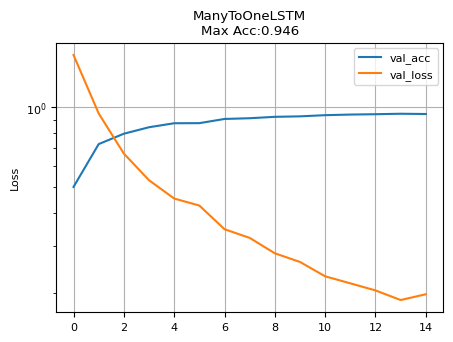

In [ ]:
plt.title(f"{name}\nMax Acc:{df['val_acc'].max():.3f}")
plt.plot(df['val_acc'], label="val_acc")
plt.plot(df['val_loss'], label="val_loss")
plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

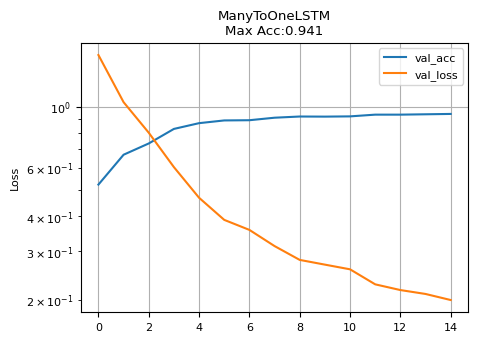

#### Plot

### **Model-2** : Bidirectional Model

#### Define

In [ ]:
class BidirectionalRNN(Wrap_10):
    def __init__(self, features, in_dense, lstm_units, out_dense, batch_first=True):
        super(BidirectionalRNN, self).__init__()
        self.inLinear = nn.Linear(features, in_dense)
        self.lstm = nn.LSTM(input_size=in_dense, hidden_size=lstm_units,
                            batch_first=batch_first, bidirectional=True)
        self.outLinear = nn.Linear(lstm_units*2, out_dense)

    def forward(self, x):
        #(bs,28,28)<-(bs,1,28,28)
        x = x.reshape(x.size(0),x.size(2),-1)
        out = self.inLinear(x)
        out, (hn, cn) = self.lstm(out)
        out = self.outLinear(out[:, -1, :])
        return out

model = BidirectionalRNN(features, in_dense, lstm_units, out_dense)#.to(device)
summary(model, input_size=(batch_size, 1, time_steps, features))

Layer (type:depth-idx)                   Output Shape              Param #
BidirectionalRNN                         [512, 10]                 --
├─Linear: 1-1                            [512, 28, 64]             1,856
├─LSTM: 1-2                              [512, 28, 32]             10,496
├─Linear: 1-3                            [512, 10]                 330
Total params: 12,682
Trainable params: 12,682
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 151.59
Input size (MB): 1.61
Forward/backward pass size (MB): 11.05
Params size (MB): 0.05
Estimated Total Size (MB): 12.71

#### Compile

#### Fit

In [ ]:
%%time
model = BidirectionalRNN(features, in_dense, lstm_units, out_dense)

name = "BidirectionalRNN"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=15, logger=logger,)
trainer.fit(model, train_loader, test_loader)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name      | Type   |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


CPU times: user 20.5 s, sys: 4.81 s, total: 25.3 s
Wall time: 37.6 s


Wall time: 39.8 s

#### **Analysis**

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df2 = history.groupby('epoch').last().drop('step', axis=1)
print('\t',df2['val_acc'].max())

	 0.9330000281333924


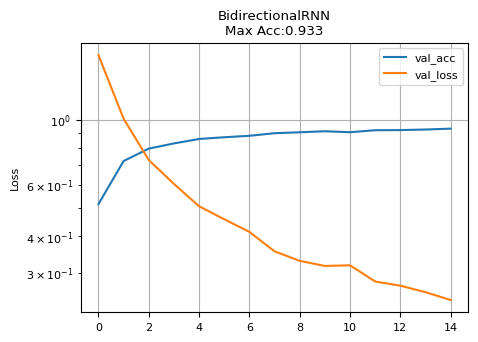

In [ ]:
plt.title(f"{name}\nMax Acc:{df2['val_acc'].max():.3f}")
plt.plot(df2['val_acc'], label="val_acc")
plt.plot(df2['val_loss'], label="val_loss")
plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

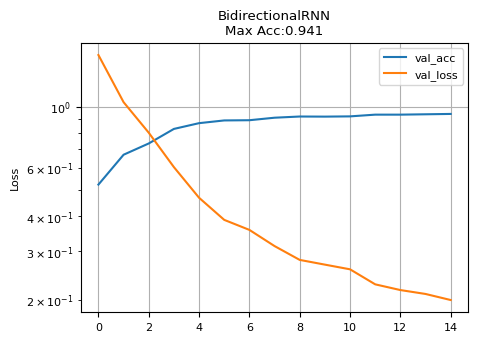

####두모델 비교




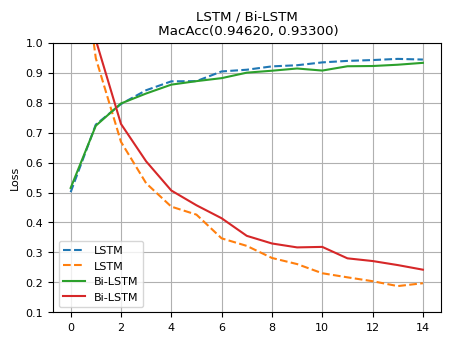

In [ ]:
plt.title(f"LSTM / Bi-LSTM\n MacAcc({df['val_acc'].max():.5f}, {df2['val_acc'].max():.5f})")
plt.plot(df['val_acc'], linestyle='--', label="LSTM")
plt.plot(df['val_loss'], linestyle='--', label="LSTM")
plt.plot(df2['val_acc'], linestyle='-', label="Bi-LSTM")
plt.plot(df2['val_loss'], linestyle='-', label="Bi-LSTM")
plt.ylim(0.1,1)
#plt.semilogy()
plt.grid()
plt.legend()
plt.ylabel('Loss')
plt.legend()
plt.show()

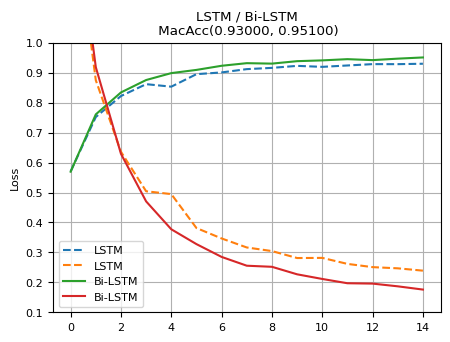

## **실습 과제**   
### 과제 1
- ManyToOneLSTM모델에서 LSTM 출력을 모두 사용하고,  
  Flatten Layer를 추가하여 ManyToOne으로 수정해 보자  
- 성능 변화를 예측해 보고, 결과를 비교해 보자    

### 과제 2
- 과제1의 모델에서 LSTM units을 늘려 보자   
  늘리면 계속 성능이 증가 할까?  
  최적의 units를 찾아 보자    

### 과제 3  
- 과제 2 모델을 BidirectionalLSTM으로 수정하여  
 성능 향상이 있는지 확인해 보자  